## PRCP-1002-Handwritten Digits Recognition

## 1.Business Problem Understanding


### Business Problem Understanding

Handwritten digit recognition is a classic computer vision problem where the objective is to correctly classify handwritten numerical digits (0–9) from image data.

### Business Objective:
To build and compare multiple machine learning and deep learning models that can accurately classify handwritten digits.

### Business Use Cases:
- Optical Character Recognition (OCR)
- Bank cheque processing
- Postal code recognition
- Form digitization
- Automated data entry systems


## 2.Dataset Description

### Dataset Description

The MNIST dataset consists of grayscale images of handwritten digits.

- Source: MNIST (Modified National Institute of Standards and Technology)
- Total Images: 70,000
- Training Images: 60,000
- Testing Images: 10,000
- Image Size: 28 × 28 pixels
- Input Feature: Image pixels
- Output Feature: Digit class (0–9)


## 3.Import Required Libraries

In [1]:
import warnings  # ignore the future warnings  
warnings.filterwarnings("ignore", category=FutureWarning)


In [3]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
#here we can see how we import libraries  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical


## 4.Load Datasetd 

In [5]:
#here how to deploy the dataset and how to implement it
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


## 5. Exploratory Data Analysis (EDA)

## Sample Images

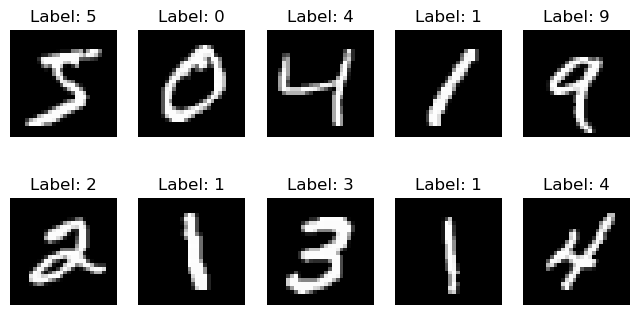

In [6]:
#from that dataset how it canbe label the images 
plt.figure(figsize=(8,4))  #sets the width to 8 inches and hieght to 4 inches.
for i in range(10):
    plt.subplot(2,5,i+1)   # 2 rows and 5 columns.
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()
#displays the image 

## Class Distribution

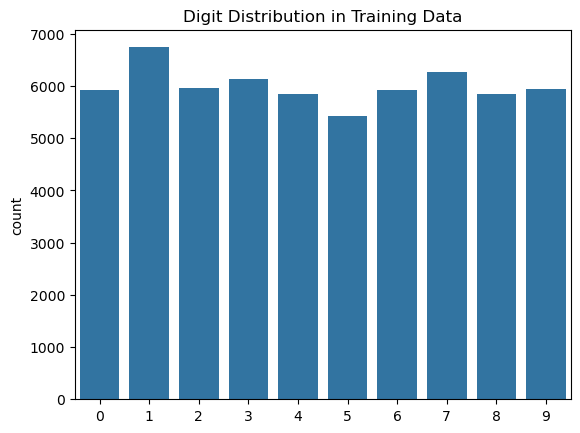

In [7]:
sns.countplot(x=y_train)
plt.title("Digit Distribution in Training Data")
plt.show()#represents the bar graph


## Pixel Value Analysis

In [8]:
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())
#here pixels can be ranging from min to max (0 to 255)

Min pixel value: 0
Max pixel value: 255


## EDA Observations :

-- it can be considered as the balanced dataset

-- No missing values present in it.

-- Pixel range is consistent from min to max.

-- Images are sequeal order from intial to final.

##  6.Data Preprocessing

## Normalization

In [9]:
X_train = X_train / 255.0  # in training MNIST images contain pixel values from 0 to 255
X_test = X_test / 255.0    # giving range from 0 to 1 


## Flattening (for ML models)

In [10]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)
#flatteing means converting a high dimension to low dimension


## 7.Model Building

## K-Nearest Neighbors (KNN)

In [11]:
#KNN algorithm 
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_flat, y_train) # train
knn_pred = knn.predict(X_test_flat)
knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)
#show the Accuracy

KNN Accuracy: 0.9705


## Support Vector Machine (SVM)

In [12]:
#SVM ALgorithm
svm = SVC(kernel='rbf')
svm.fit(X_train_flat[:10000], y_train[:10000])
svm_pred = svm.predict(X_test_flat[:2000])#Etrains the data
svm_acc = accuracy_score(y_test[:2000], svm_pred)
print("SVM Accuracy:", svm_acc)#results the accuracy

SVM Accuracy: 0.9445


## Logistic Regression

In [13]:
#Logistic Regression model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_flat[:10000], y_train[:10000]) # reduced for speed
lr_pred = lr.predict(X_test_flat[:2000])
lr_acc = accuracy_score(y_test[:2000], lr_pred)
print("Logistic Regression Accuracy:", lr_acc)
#accuracy

Logistic Regression Accuracy: 0.87


## Artificial Neural Network (ANN)


In [36]:
#Artificial Neural Network
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
#model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train_cat,
          epochs=5,
          batch_size=32,
          validation_split=0.1)


C:\Users\bhanu\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9228 - loss: 0.2722 - val_accuracy: 0.9643 - val_loss: 0.1342
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9650 - loss: 0.1185 - val_accuracy: 0.9750 - val_loss: 0.0906
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9759 - loss: 0.0807 - val_accuracy: 0.9747 - val_loss: 0.0941
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9812 - loss: 0.0608 - val_accuracy: 0.9767 - val_loss: 0.0804
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9863 - loss: 0.0459 - val_accuracy: 0.9750 - val_loss: 0.0848


## 8.Model Evaluation

In [37]:
loss, ann_acc = model.evaluate(X_test, y_test_cat)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9735 - loss: 0.0868


## Classification Report & Confusion Matrix

ann_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, ann_pred))

cm = confusion_matrix(y_test, ann_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()


## 9.Model Comparison

 Model	              Accuracy	       Remarks

KNN	                  High	           Slow prediction
SVM	                  Good	           Computationally expensive
Logistic Regression	  Moderate	       Fast but limited
ANN	                  Highest	       Best performance

## 10. Final Model Selection

## Selected Model: Artificial Neural Network (ANN)
Reasons:

--Highest accuracy

--Handles high-dimensional image data

--Learns complex patterns

--Scalable for real-world applications

## 11.Prediction on New Data


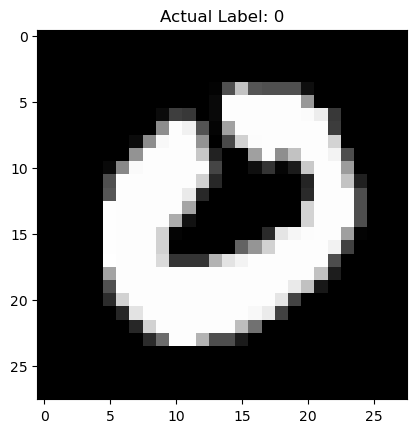

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Predicted Digit: 0


In [38]:
#predict of new data for to check running or not.
index = 25
image = X_test[index]

plt.imshow(image, cmap='gray')
plt.title(f"Actual Label: {y_test[index]}")
plt.show()

prediction = np.argmax(model.predict(image.reshape(1,28,28)))
print("Predicted Digit:", prediction)
#performing or not for new dataset

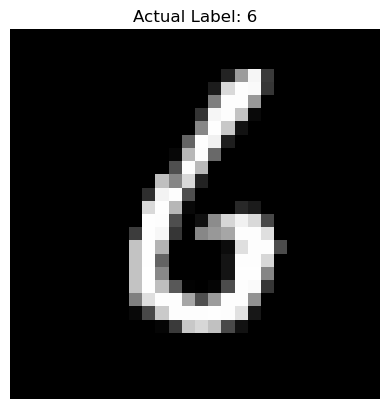

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Digit: 6


In [39]:
index = 50
image = X_test[index]

plt.imshow(image, cmap='gray')
plt.title(f"Actual Label: {y_test[index]}")
plt.axis('off')
plt.show()

prediction = np.argmax(model.predict(image.reshape(1,28,28)))
print("Predicted Digit:", prediction)


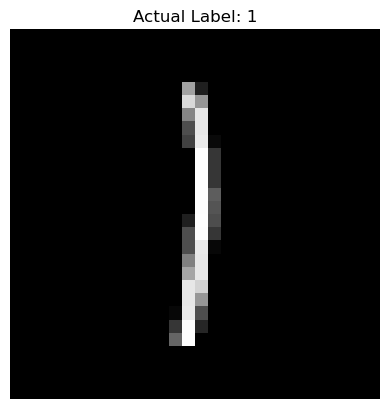

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Digit: 1


In [40]:
index = 40
image = X_test[index]

plt.imshow(image, cmap='gray')
plt.title(f"Actual Label: {y_test[index]}")
plt.axis('off')
plt.show()

prediction = np.argmax(model.predict(image.reshape(1,28,28)))
print("Predicted Digit:", prediction)


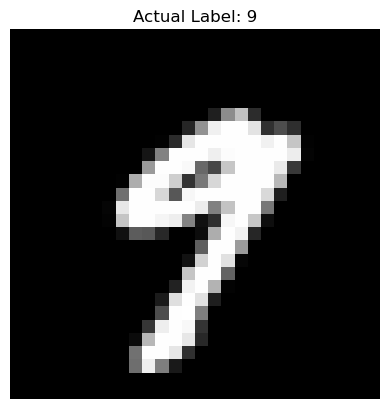

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Digit: 9


In [41]:
index = 20
image = X_test[index]

plt.imshow(image, cmap='gray')
plt.title(f"Actual Label: {y_test[index]}")
plt.axis('off')
plt.show()

prediction = np.argmax(model.predict(image.reshape(1,28,28)))
print("Predicted Digit:", prediction)


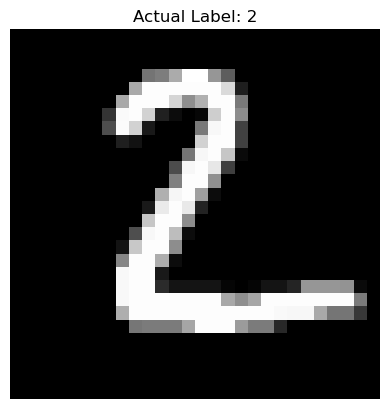

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Digit: 2


In [42]:
index = 1
image = X_test[index]

plt.imshow(image, cmap='gray')
plt.title(f"Actual Label: {y_test[index]}")
plt.axis('off')
plt.show()

prediction = np.argmax(model.predict(image.reshape(1,28,28)))
print("Predicted Digit:", prediction)


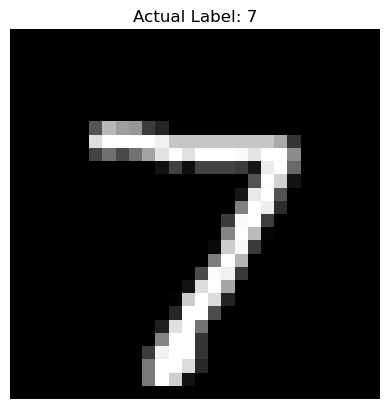

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted Digit: 7


In [43]:
index = 0
image = X_test[index]

plt.imshow(image, cmap='gray')
plt.title(f"Actual Label: {y_test[index]}")
plt.axis('off')
plt.show()

prediction = np.argmax(model.predict(image.reshape(1,28,28)))
print("Predicted Digit:", prediction)


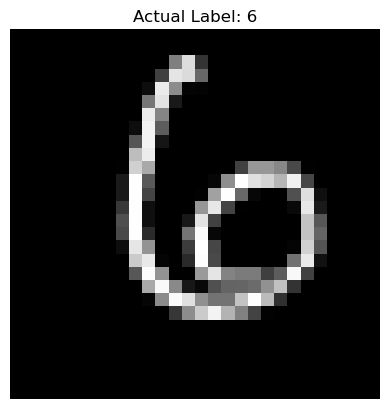

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Digit: 6


In [44]:
index = 100
image = X_test[index]

plt.imshow(image, cmap='gray')
plt.title(f"Actual Label: {y_test[index]}")
plt.axis('off')
plt.show()

prediction = np.argmax(model.predict(image.reshape(1,28,28)))
print("Predicted Digit:", prediction)


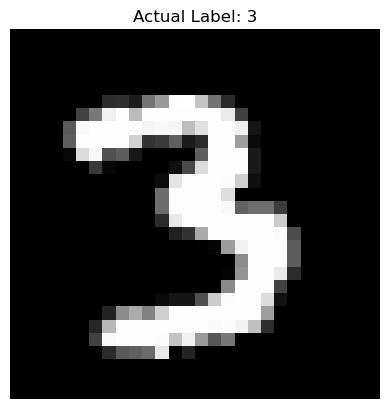

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Digit: 3


In [45]:
index = 500
image = X_test[index]

plt.imshow(image, cmap='gray')
plt.title(f"Actual Label: {y_test[index]}")
plt.axis('off')
plt.show()

prediction = np.argmax(model.predict(image.reshape(1,28,28)))
print("Predicted Digit:", prediction)


## 12.Challenges & Learnings

## 13.Conclusion

## 14.Future Scope

## Final Conclusion
